## Penugasan 2 – Perbandingan Metode Peningkatan Kontras

### Deskripsi
Dua metode peningkatan kontras dibandingkan pada citra grayscale berkontras rendah:
- **Contrast Stretching** (`rescale_intensity`): meregangkan rentang intensitas secara linear dari range sempit ke range penuh [0, 1]
- **Histogram Equalization** (`equalize_hist`): mendistribusikan ulang intensitas piksel agar histogram merata di seluruh rentang

Intensitas min: 0.200, max: 0.600
Is low contrast: False


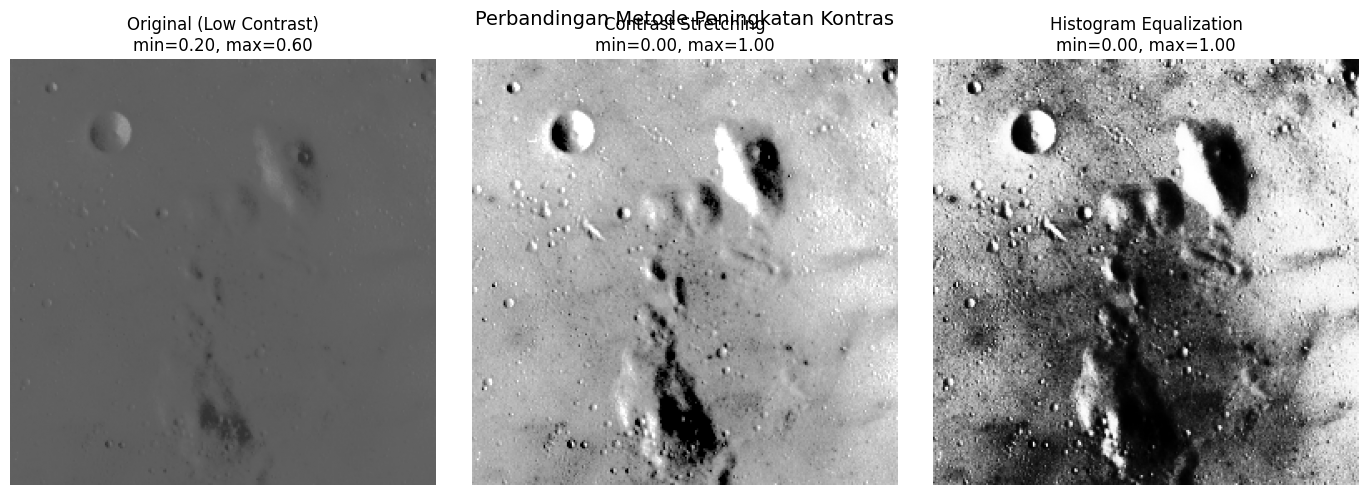

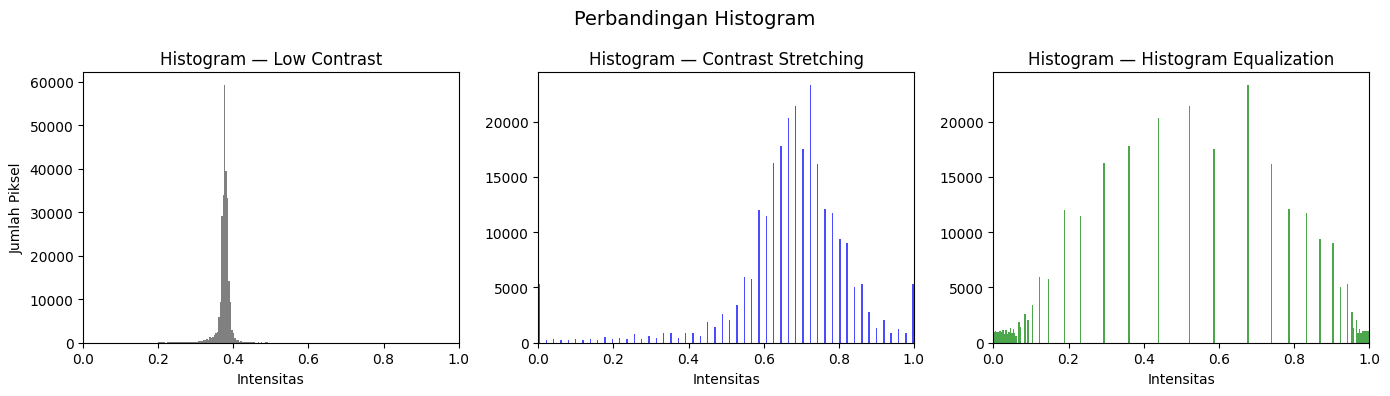


=== Metrik Perbandingan ===
Rentang intensitas - Low Contrast    : 0.4000
Rentang intensitas - Contrast Stretch: 1.0000
Rentang intensitas - Hist Equalized  : 0.9991
Std deviasi - Low Contrast    : 0.0209
Std deviasi - Contrast Stretch: 0.1658
Std deviasi - Hist Equalized  : 0.2899


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float, exposure

# --------------------------------------------------
# PERSIAPAN: BUAT CITRA BERKONTRAS RENDAH
# Gunakan citra moon yang secara natural gelap/kontras rendah,
# lalu perkuat efeknya dengan rescale ke rentang sempit
# --------------------------------------------------

img_original = img_as_float(data.moon())

# Simulasi citra berkontras rendah: rentang intensitas dipersempit ke [0.2, 0.6]
img_low_contrast = exposure.rescale_intensity(img_original, out_range=(0.2, 0.6))

print(f"Intensitas min: {img_low_contrast.min():.3f}, max: {img_low_contrast.max():.3f}")
print(f"Is low contrast: {exposure.is_low_contrast(img_low_contrast)}")

# --------------------------------------------------
# METODE 1: CONTRAST STRETCHING (rescale_intensity)
# in_range=(p2, p98) → memotong 2% piksel outlier di tiap ujung
# out_range=(0, 1)   → meregangkan ke rentang penuh
# --------------------------------------------------

p2, p98 = np.percentile(img_low_contrast, (2, 98))
img_contrast_stretched = exposure.rescale_intensity(
    img_low_contrast,
    in_range=(p2, p98),
    out_range=(0.0, 1.0)
)

# --------------------------------------------------
# METODE 2: HISTOGRAM EQUALIZATION (equalize_hist)
# nbins=256 → jumlah bin histogram yang digunakan
# --------------------------------------------------

img_equalized = exposure.equalize_hist(img_low_contrast, nbins=256)

# --------------------------------------------------
# PLOTTING: PERBANDINGAN CITRA
# --------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Perbandingan Metode Peningkatan Kontras", fontsize=14)

axes[0].imshow(img_low_contrast, cmap='gray', vmin=0, vmax=1)
axes[0].set_title(f"Original (Low Contrast)\nmin={img_low_contrast.min():.2f}, max={img_low_contrast.max():.2f}")
axes[0].axis('off')

axes[1].imshow(img_contrast_stretched, cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f"Contrast Stretching\nmin={img_contrast_stretched.min():.2f}, max={img_contrast_stretched.max():.2f}")
axes[1].axis('off')

axes[2].imshow(img_equalized, cmap='gray', vmin=0, vmax=1)
axes[2].set_title(f"Histogram Equalization\nmin={img_equalized.min():.2f}, max={img_equalized.max():.2f}")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# --------------------------------------------------
# PLOTTING: PERBANDINGAN HISTOGRAM
# --------------------------------------------------

fig2, axes2 = plt.subplots(1, 3, figsize=(14, 4))
fig2.suptitle("Perbandingan Histogram", fontsize=14)

axes2[0].hist(img_low_contrast.ravel(), bins=256, range=(0, 1), color='gray')
axes2[0].set_title("Histogram — Low Contrast")
axes2[0].set_xlim(0, 1)
axes2[0].set_xlabel("Intensitas")
axes2[0].set_ylabel("Jumlah Piksel")

axes2[1].hist(img_contrast_stretched.ravel(), bins=256, range=(0, 1), color='blue', alpha=0.7)
axes2[1].set_title("Histogram — Contrast Stretching")
axes2[1].set_xlim(0, 1)
axes2[1].set_xlabel("Intensitas")

axes2[2].hist(img_equalized.ravel(), bins=256, range=(0, 1), color='green', alpha=0.7)
axes2[2].set_title("Histogram — Histogram Equalization")
axes2[2].set_xlim(0, 1)
axes2[2].set_xlabel("Intensitas")

plt.tight_layout()
plt.show()

# --------------------------------------------------
# METRIK PERBANDINGAN
# --------------------------------------------------

def contrast_ratio(img):
    return img.max() - img.min()

print("\n=== Metrik Perbandingan ===")
print(f"Rentang intensitas - Low Contrast    : {contrast_ratio(img_low_contrast):.4f}")
print(f"Rentang intensitas - Contrast Stretch: {contrast_ratio(img_contrast_stretched):.4f}")
print(f"Rentang intensitas - Hist Equalized  : {contrast_ratio(img_equalized):.4f}")
print(f"Std deviasi - Low Contrast    : {img_low_contrast.std():.4f}")
print(f"Std deviasi - Contrast Stretch: {img_contrast_stretched.std():.4f}")
print(f"Std deviasi - Hist Equalized  : {img_equalized.std():.4f}")

### Kesimpulan
Contrast stretching menggunakan `rescale_intensity` dengan parameter `in_range=(p2, p98)` dan `out_range=(0, 1)` memetakan rentang intensitas sempit secara linear ke rentang penuh [0, 1]. Hasilnya adalah peningkatan kontras yang proporsional — distribusi relatif antar piksel tetap sama, hanya skalanya yang diperluas. Metode ini cocok bila distribusi intensitas citra sudah cukup merata namun hanya terkonsentrasi pada rentang yang sempit.

Histogram equalization menggunakan `equalize_hist` dengan `nbins=256` mendistribusikan ulang intensitas secara non-linear agar histogram menjadi serata mungkin. Hasilnya lebih agresif — detail pada area gelap maupun terang sama-sama diperkuat. Namun pada area yang sudah cukup kontras, metode ini dapat menyebabkan over-enhancement. Secara umum, histogram equalization lebih efektif meningkatkan kontras global pada citra yang intensitasnya sangat terkonsentrasi di satu rentang sempit, sementara contrast stretching lebih aman dan terprediksi untuk citra yang hanya membutuhkan penyesuaian skala.